# 24 Final Thesis Figures

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "24_visual_polish_figures"
FIGURE_DIR = NOTEBOOK_OUTPUT_DIR / "figures"
TABLE_DIR = NOTEBOOK_OUTPUT_DIR / "tables"
DATA_OUTPUT_DIR = NOTEBOOK_OUTPUT_DIR / "data"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENDER_ORDER = ["MM", "MW", "WM", "WW"]
SLICE_ORDER = ["All→CS", "CS→CS"]

cross = pd.read_csv(
    PROJECT_ROOT
    / "outputs"
    / "23_cross_baseline_robustness"
    / "tables"
    / "cross_baseline_unified_oe_long.csv"
)

fine_lag = pd.read_csv(
    PROJECT_ROOT
    / "outputs"
    / "17_long_memory_citation_flow"
    / "tables"
    / "long_memory_fine_lag_oe_by_gender.csv"
)

cross["gender_cat"] = cross["gender_cat"].astype(str)
cross["citation_slice"] = cross["citation_slice"].astype(str)
cross["baseline_id"] = cross["baseline_id"].astype(str)
cross["oe_ratio"] = pd.to_numeric(cross["oe_ratio"], errors="coerce")

## Network-Neighborhood Comparison

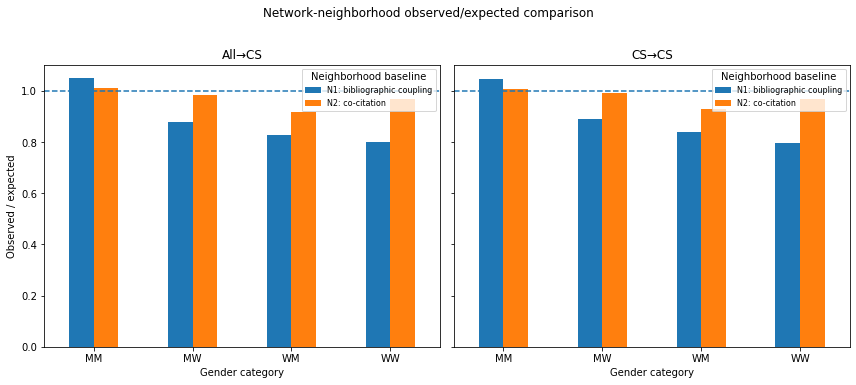

In [2]:
def extract_oe_matrix(baseline_ids, citation_slice):
    z = cross[
        cross["baseline_id"].isin(baseline_ids)
        & cross["citation_slice"].eq(citation_slice)
    ].copy()

    return (
        z.pivot(
            index="gender_cat",
            columns="baseline_id",
            values="oe_ratio",
        )
        .reindex(GENDER_ORDER)
        .reindex(columns=baseline_ids)
    )

n1n2_all = extract_oe_matrix(["N1", "N2"], "All→CS")
n1n2_cs = extract_oe_matrix(["N1", "N2"], "CS→CS")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True)

for ax, sl, mat in zip(
    axes,
    SLICE_ORDER,
    [n1n2_all, n1n2_cs],
):
    plot_df = mat.rename(
        columns={
            "N1": "N1: bibliographic coupling",
            "N2": "N2: co-citation",
        }
    )
    plot_df.plot(kind="bar", ax=ax)
    ax.axhline(1, linestyle="--")
    ax.set_title(sl)
    ax.set_xlabel("Gender category")
    ax.set_ylabel("Observed / expected")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Neighborhood baseline", fontsize=8)

fig.suptitle(
    "Network-neighborhood observed/expected comparison",
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "network_neighborhood_n1_n2_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## GLM M1–M5 Comparison

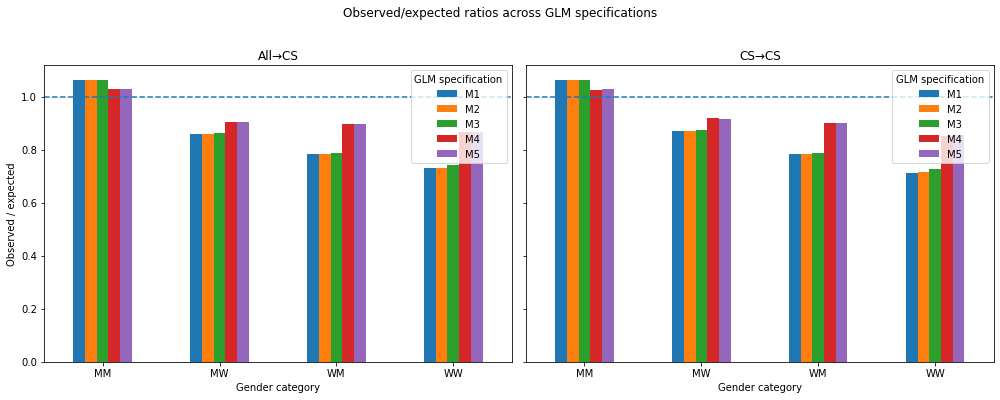

In [3]:
glm_ids = ["M1", "M2", "M3", "M4", "M5"]

glm_all = extract_oe_matrix(glm_ids, "All→CS")
glm_cs = extract_oe_matrix(glm_ids, "CS→CS")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharey=True)

for ax, sl, mat in zip(
    axes,
    SLICE_ORDER,
    [glm_all, glm_cs],
):
    mat.plot(kind="bar", ax=ax)
    ax.axhline(1, linestyle="--")
    ax.set_title(sl)
    ax.set_xlabel("Gender category")
    ax.set_ylabel("Observed / expected")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="GLM specification")

fig.suptitle(
    "Observed/expected ratios across GLM specifications",
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "glm_oe_m1_m5_combined_slices.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Network-Conditioned Randomization Comparison

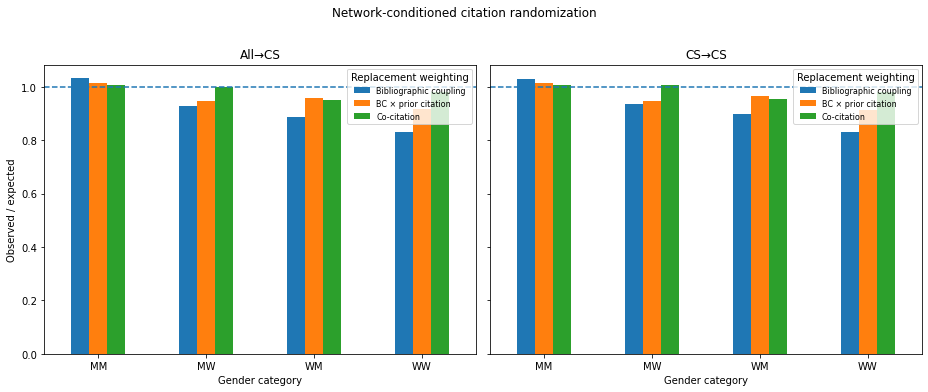

In [4]:
random_ids = ["NR_BC", "NR_BC_prior", "NR_CO"]

random_all = extract_oe_matrix(random_ids, "All→CS")
random_cs = extract_oe_matrix(random_ids, "CS→CS")

rename_random = {
    "NR_BC": "Bibliographic coupling",
    "NR_BC_prior": "BC × prior citation",
    "NR_CO": "Co-citation",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3), sharey=True)

for ax, sl, mat in zip(
    axes,
    SLICE_ORDER,
    [random_all, random_cs],
):
    mat.rename(columns=rename_random).plot(kind="bar", ax=ax)
    ax.axhline(1, linestyle="--")
    ax.set_title(sl)
    ax.set_xlabel("Gender category")
    ax.set_ylabel("Observed / expected")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Replacement weighting", fontsize=8)

fig.suptitle(
    "Network-conditioned citation randomization",
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "network_randomization_three_way_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Fine-Grained Citation-Lag Comparison

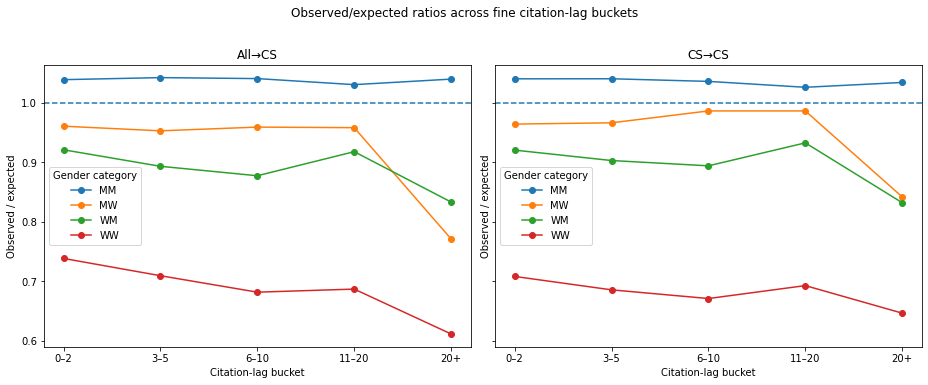

In [5]:
fine_lag["_slice"] = fine_lag["citation_slice"].astype(str)
fine_lag["_gender"] = fine_lag["gender_cat"].astype(str).str.upper()
fine_lag["_bucket"] = (
    fine_lag["fine_bucket"]
    .astype(str)
    .str.replace("–", "-", regex=False)
    .str.replace("—", "-", regex=False)
)
fine_lag["_oe"] = pd.to_numeric(fine_lag["oe_ratio"], errors="coerce")

LAG_ORDER = ["0-2", "3-5", "6-10", "11-20", "20+"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)

for ax, sl in zip(axes, SLICE_ORDER):
    z = fine_lag[
        fine_lag["_slice"].eq(sl)
        & fine_lag["_gender"].isin(GENDER_ORDER)
        & fine_lag["_bucket"].isin(LAG_ORDER)
    ].copy()

    piv = (
        z.pivot(
            index="_bucket",
            columns="_gender",
            values="_oe",
        )
        .reindex(LAG_ORDER)
        .reindex(columns=GENDER_ORDER)
    )

    for gender in GENDER_ORDER:
        ax.plot(
            np.arange(len(LAG_ORDER)),
            piv[gender].to_numpy(),
            marker="o",
            label=gender,
        )

    ax.axhline(1, linestyle="--")
    ax.set_xticks(np.arange(len(LAG_ORDER)))
    ax.set_xticklabels(["0–2", "3–5", "6–10", "11–20", "20+"])
    ax.set_title(sl)
    ax.set_xlabel("Citation-lag bucket")
    ax.set_ylabel("Observed / expected")
    ax.legend(title="Gender category")

fig.suptitle(
    "Observed/expected ratios across fine citation-lag buckets",
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "long_memory_fine_lag_oe_combined_slices.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Gender-to-Gender Citation Composition

In [6]:
def standardize_edges(edges):
    out = edges[["citing_paper_id", "cited_paper_id"]].copy()
    out["citing_paper_id"] = out["citing_paper_id"].astype(str)
    out["cited_paper_id"] = out["cited_paper_id"].astype(str)
    return out

papers = pd.read_pickle(PROCESSED_DIR / "papers_final.pkl")

all_to_cs_edges = standardize_edges(
    pd.read_pickle(PROCESSED_DIR / "citation_edges_all_to_cs_final.pkl")
)
cs_to_cs_edges = standardize_edges(
    pd.read_pickle(PROCESSED_DIR / "citation_edges_cs_to_cs_final.pkl")
)

gender_map = (
    papers[["id", "first_last_cat"]]
    .assign(
        paper_id=lambda d: d["id"].astype(str),
        gender_cat=lambda d: d["first_last_cat"].astype(str).str.upper(),
    )
    .set_index("paper_id")["gender_cat"]
)

def gender_flow_matrix(edges):
    x = edges.copy()
    x["citing_gender"] = x["citing_paper_id"].map(gender_map)
    x["cited_gender"] = x["cited_paper_id"].map(gender_map)

    x = x[
        x["citing_gender"].isin(GENDER_ORDER)
        & x["cited_gender"].isin(GENDER_ORDER)
    ].copy()

    counts = (
        x.groupby(
            ["citing_gender", "cited_gender"],
            observed=True,
        )
        .size()
        .unstack(fill_value=0)
        .reindex(index=GENDER_ORDER, columns=GENDER_ORDER)
    )

    shares = counts.div(counts.sum(axis=1), axis=0)
    return counts, shares

flow_counts_all, flow_shares_all = gender_flow_matrix(all_to_cs_edges)
flow_counts_cs, flow_shares_cs = gender_flow_matrix(cs_to_cs_edges)

display(flow_counts_all)
display(flow_shares_all)
display(flow_counts_cs)
display(flow_shares_cs)

cited_gender,MM,MW,WM,WW
citing_gender,,,,
MM,3487153,295979,363723,131845
MW,439223,45904,58341,23117
WM,626710,65918,87788,33818
WW,211190,25075,33531,19641


cited_gender,MM,MW,WM,WW
citing_gender,,,,
MM,0.8150,0.0692,0.0850,0.0308
MW,0.7752,0.0810,0.1030,0.0408
WM,0.7697,0.0810,0.1078,0.0415
WW,0.7297,0.0866,0.1158,0.0679


cited_gender,MM,MW,WM,WW
citing_gender,,,,
MM,2837523,246238,298804,106914
MW,348822,37387,46555,17872
WM,497732,53258,69963,26290
WW,165319,19524,25846,14111


cited_gender,MM,MW,WM,WW
citing_gender,,,,
MM,0.8132,0.0706,0.0856,0.0306
MW,0.7741,0.0830,0.1033,0.0397
WM,0.7690,0.0823,0.1081,0.0406
WW,0.7354,0.0869,0.1150,0.0628


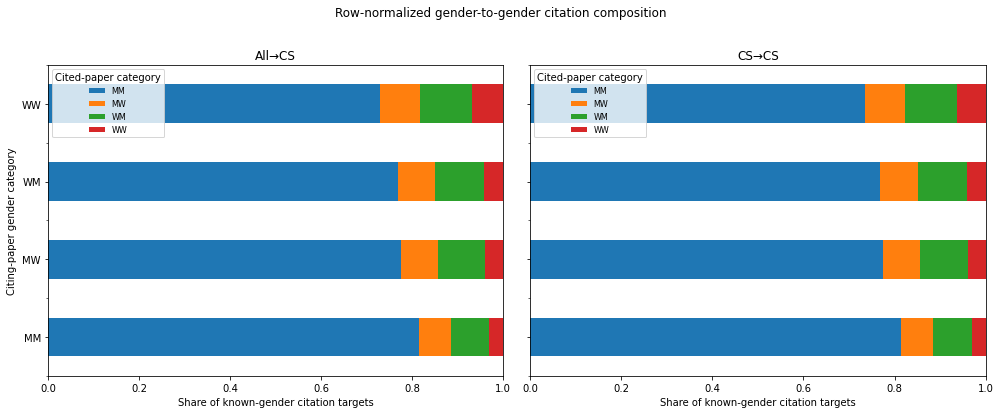

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), sharey=True)

for ax, sl, shares in zip(
    axes,
    SLICE_ORDER,
    [flow_shares_all, flow_shares_cs],
):
    shares.plot(
        kind="barh",
        stacked=True,
        ax=ax,
    )
    ax.set_title(sl)
    ax.set_xlabel("Share of known-gender citation targets")
    ax.set_ylabel("Citing-paper gender category")
    ax.set_xlim(0, 1)
    ax.legend(title="Cited-paper category", fontsize=8)

fig.suptitle(
    "Row-normalized gender-to-gender citation composition",
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "gender_to_gender_citation_flow_stacked_combined.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()